# Random Forest

- ML algorithm that uses many decision to make better predictions
- Each tree looks at different random part of the data and their results are combined by voting for classification or averaging for regression which makes it on assemble learning technique
- helps in improving accuracy and reducing errors
- create many decision tree
- pick random features
- each tree makes a prediction
- combine the predictions

### 1. Bagging(Bootstrap Aggregating)
##### it takes your dataset and creates random sample with replacement .

- if you have 100 data.
    - tree 1 - 1,5,20,50
    - tree 2 - 2,9,15,80

In [10]:
import pandas as pd
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df["Age"].fillna(df["Age"].mean(),inplace=True)
df

C:\Users\LJENG\AppData\Local\Temp\ipykernel_10748\2079956988.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [13]:
x=df[["Pclass","Sex","Age","SibSp","Parch","Fare"]]
y=df["Survived"]
print(x.shape)
print(y.shape)

(891, 6)
(891,)


In [14]:
x["Sex"]=x["Sex"].map({"female":0,"male":1})
x["Age"]=x["Age"].fillna(x["Age"].mean())

C:\Users\LJENG\AppData\Local\Temp\ipykernel_10748\3256429841.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Sex"]=x["Sex"].map({"female":0,"male":1})
C:\Users\LJENG\AppData\Local\Temp\ipykernel_10748\3256429841.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Age"]=x["Age"].fillna(x["Age"].mean())


In [15]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.000000,1,0,7.2500
1,1,0,38.000000,1,0,71.2833
2,3,0,26.000000,0,0,7.9250
3,1,0,35.000000,1,0,53.1000
4,3,1,35.000000,0,0,8.0500
...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000
887,1,0,19.000000,0,0,30.0000
888,3,0,29.699118,1,2,23.4500
889,1,1,26.000000,0,0,30.0000


In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)



(712, 6)
(712,)
(179, 6)
(179,)


In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(n_estimators=100,criterion="entropy",random_state=42)
rf_classifier.fit(x_train,y_train)
y_pred=rf_classifier.predict(x_test)
print(y_pred)

from sklearn.metrics import accuracy_score
print("accuracy: ",accuracy_score(y_test,y_pred))

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1]
accuracy:  0.770949720670391


In [28]:
sample=x_test.iloc[0:1]
print(sample)
prediction=rf_classifier.predict(sample)
prediction

     Pclass  Sex   Age  SibSp  Parch     Fare
862       1    0  48.0      0      0  25.9292


array([1])

In [29]:
sample_dict=sample.iloc[0].to_dict()
print(sample_dict)
print(f"sample passenger data:{sample_dict}")
print(f"predicted survival:{'survived' if prediction[0]==1 else 'Not survived'}")

{'Pclass': 1.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 25.9292}
sample passenger data:{'Pclass': 1.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 25.9292}
predicted survival:survived


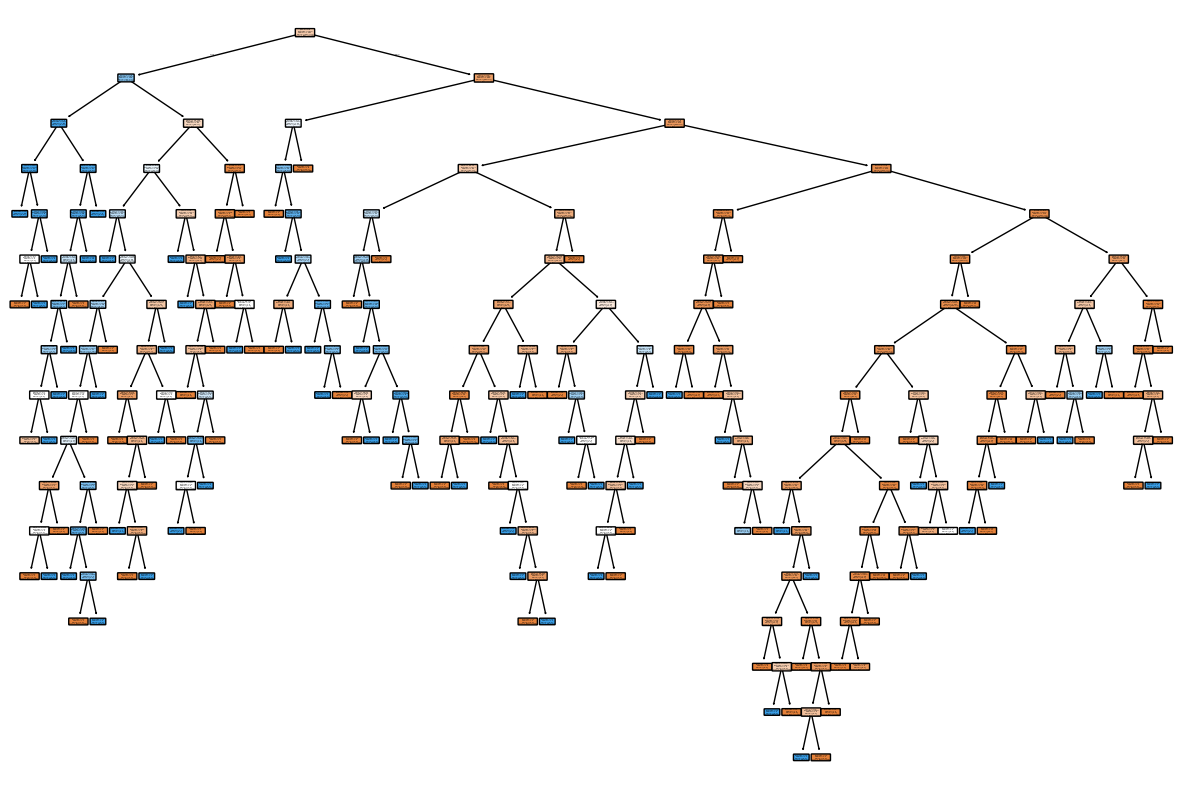

In [31]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
chosen_tree=rf_classifier.estimators_[0]
plt.figure(figsize=(15,10))
plot_tree(chosen_tree,feature_names=x.columns,class_names=["Not Survived","Survived"],filled=True,rounded=True)
plt.show()

In [32]:
import pandas as pd
df=pd.DataFrame({"Weight":[150,170,140,180,160,155],"Texture":["smooth","Rough","smooth","Rough","smooth","Rough"],"Color":["Red","Orange","Green","Orange","Red","Yellow"],
                "Fruit":["Apple","orange","Apple","orange","Apple","orange"]})
df

,Weight,Texture,Color,Fruit
0,150,smooth,Red,Apple
1,170,Rough,Orange,orange
2,140,smooth,Green,Apple
3,180,Rough,Orange,orange
4,160,smooth,Red,Apple
5,155,Rough,Yellow,orange


In [34]:
import numpy as np
df["Texture"]=np.where(df["Texture"]=="smooth",1,0)
df["Color"]=np.where(df["Color"]=='Red',0,np.where(df['Color']=="Orange",1,np.where(df["Color"]=="Green",2,3)))
df

,Weight,Texture,Color,Fruit
0,150,1,0,Apple
1,170,0,1,orange
2,140,1,2,Apple
3,180,0,1,orange
4,160,1,0,Apple
5,155,0,3,orange


In [37]:
x=df[["Weight","Texture","Color"]]
y=df["Fruit"]
print(x.shape)
print(y.shape)

from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(n_estimators=10,criterion="entropy",random_state=42)
rf_classifier.fit(x,y)
y_pred=rf_classifier.predict(x)
print(y_pred)

from sklearn.metrics import accuracy_score
print("accuracy: ",accuracy_score(y,y_pred))

(6, 3)
(6,)
['Apple' 'orange' 'Apple' 'orange' 'Apple' 'orange']
accuracy:  1.0


In [38]:
sample=x.iloc[0:1]
print(sample)
prediction=rf_classifier.predict(sample)
prediction

   Weight  Texture  Color
0     150        1      0


array(['Apple'], dtype=object)

In [39]:
sample_dict=sample.iloc[0].to_dict()
print(sample_dict)
print(f"sample data:{sample_dict}")
print(f"predicted survival:{'survived' if prediction[0]=="Apple" else 'Not survived'}")

{'Weight': 150, 'Texture': 1, 'Color': 0}
sample data:{'Weight': 150, 'Texture': 1, 'Color': 0}
predicted survival:survived


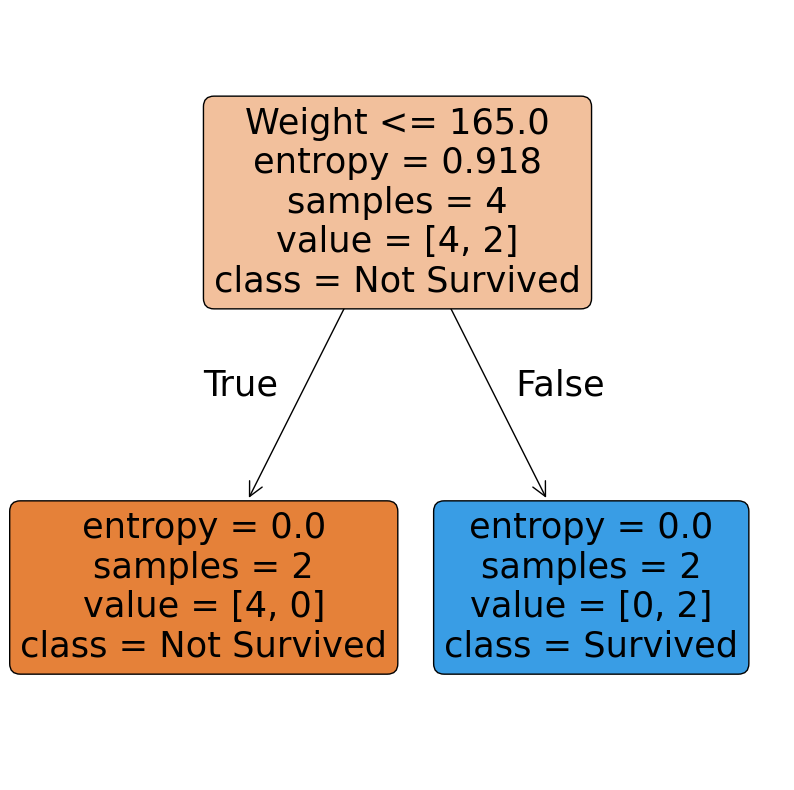

In [41]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
chosen_tree=rf_classifier.estimators_[0]
plt.figure(figsize=(10,10))
plot_tree(chosen_tree,feature_names=x.columns,class_names=["Not Survived","Survived"],filled=True,rounded=True)
plt.show()

# Support Vector Machine
- SVM is complex classification tasks
- SVM looks for the optimal hyperplane that best separates different classes in a dataset
#### Decision boundary - line that separates the classes
#### Margin - Distance between the line and the nearest points of each class
#### Support vectors - data points that sit right at the edge of the decision boundary. These are most important points beacsuse if you move them boundary moves

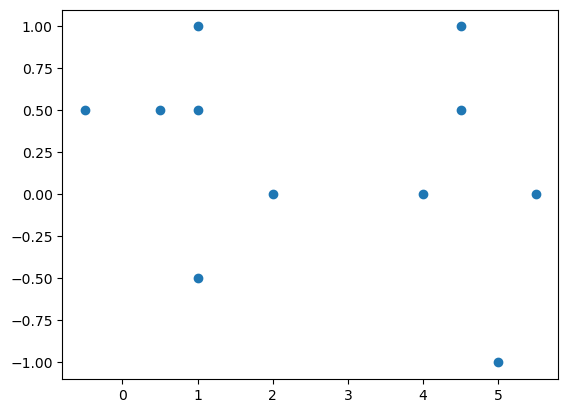

In [42]:
x=[1,1,1,-0.5,0.5,2,4,4.5,4.5,5,5.5]
y=[0.5,1,-0.5,0.5,0.5,0,0,1,0.5,-1,0]
plt.scatter(x,y)

In [43]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [44]:
x=df.iloc[:,0:8]
y=df["Outcome"]
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [45]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(614, 8)
(614,)
(154, 8)
(154,)


In [47]:
from sklearn.svm import SVC
classifier=SVC(kernel="rbf",C=1.0,random_state=1)
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
print(y_pred)

from sklearn.metrics import accuracy_score
print("accuracy: ",accuracy_score(y_test,y_pred))

[0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0]
accuracy:  0.7857142857142857
